# Linear Discriminant Analysis

Let $Y$ denote the outcome of a $K$ class classifier. Looking to estimate:
$$
P(Y = k | X = x)
$$

or $P(Y|X)$ for short. Let $f_k(x)$ denote the class-conditional density function of $X$.
$$
f_k(x) = P(X = x | Y = k)
$$

From Bayes' Rule, we get
$$
P(Y=k|X=x) = \frac{f_k(x) \pi_k}{\sum_{j=1}^K f_j(x) \pi_j}
$$

where $\pi_k = P(Y = k)$.

So we can decide classes if we can compute the $f_k(x)$. Assume the $f_k(x)$ are (multivariate) normal variables.

If we compare two classes $k$ and $j$, we can look at the log-probability ratio

\begin{align*}
\log \frac{P(Y = k | X= x)}{P(Y=j | X = x)} &= \log \frac{f_k(x)}{f_j(x)} + \log \frac{\pi_k}{\pi_j} \\
&= -\frac{1}{2} \langle(\mu_k + \mu_j), \Sigma^{-1} (\mu_k - \mu_j) \rangle + \langle x, \Sigma^{-1} (\mu_k - \mu_j)\rangle + \log \frac{\pi_k}{\pi_j}
\end{align*}

For LDA, we assume that the covariance is common to all classes.

# Regularization

We can add a regularization parameter $\lambda$ and define the regularized covariance matrix
$$
\Sigma_\lambda = \lambda \Sigma + (1-\lambda)\mbox{diag}(\Sigma)
$$

where the second term is simply the diagonal of the original covariance matrix.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import statsmodels.api as sm

matplotlib.rcParams['figure.figsize'] = (20, 10)

In [ ]:
def generate_classifier_data(c_1, c_2, c_3, sigma, size_1, size_2, size_3, seed):
  rng = numpy.random.default_rng(seed=seed)
  class1 = rng.multivariate_normal(c_1, sigma, size=size_1)
  class2 = rng.multivariate_normal(c_2, sigma, size=size_2)
  class3 = rng.multivariate_normal(c_3, sigma, size=size_3)
  ys1 = numpy.zeros(shape=(class1.shape[0],1))
  ys2 = numpy.ones(shape=(class2.shape[0], 1))
  ys3 = 2*numpy.ones(shape=(class3.shape[0],1))
  xs = numpy.vstack((class1, class2, class3))
  ys = numpy.vstack((ys1, ys2, ys3))
  return (xs, ys)


In [ ]:
rng = numpy.random.default_rng(seed=571295)
c_1 = rng.uniform(high=10, low=-10, size=1000)
c_2 = rng.uniform(high=10, low=-10, size=1000)
c_3 = rng.uniform(high=10, low=-10, size=1000)
sigma_12 = rng.uniform(high=10, low=-10, size=(1000,1000))
sigma = numpy.matmul(sigma_12.T, sigma_12)#numpy.array([[1, 0], [0, 1]])
c1_size = 300
c2_size = 100
c3_size = 50
xs, ys = generate_classifier_data(c_1, c_2,c_3, sigma, c1_size, c2_size, c3_size, 8675309)

In [ ]:
xs.shape

(450, 1000)

In [ ]:
ys.shape

(450, 1)

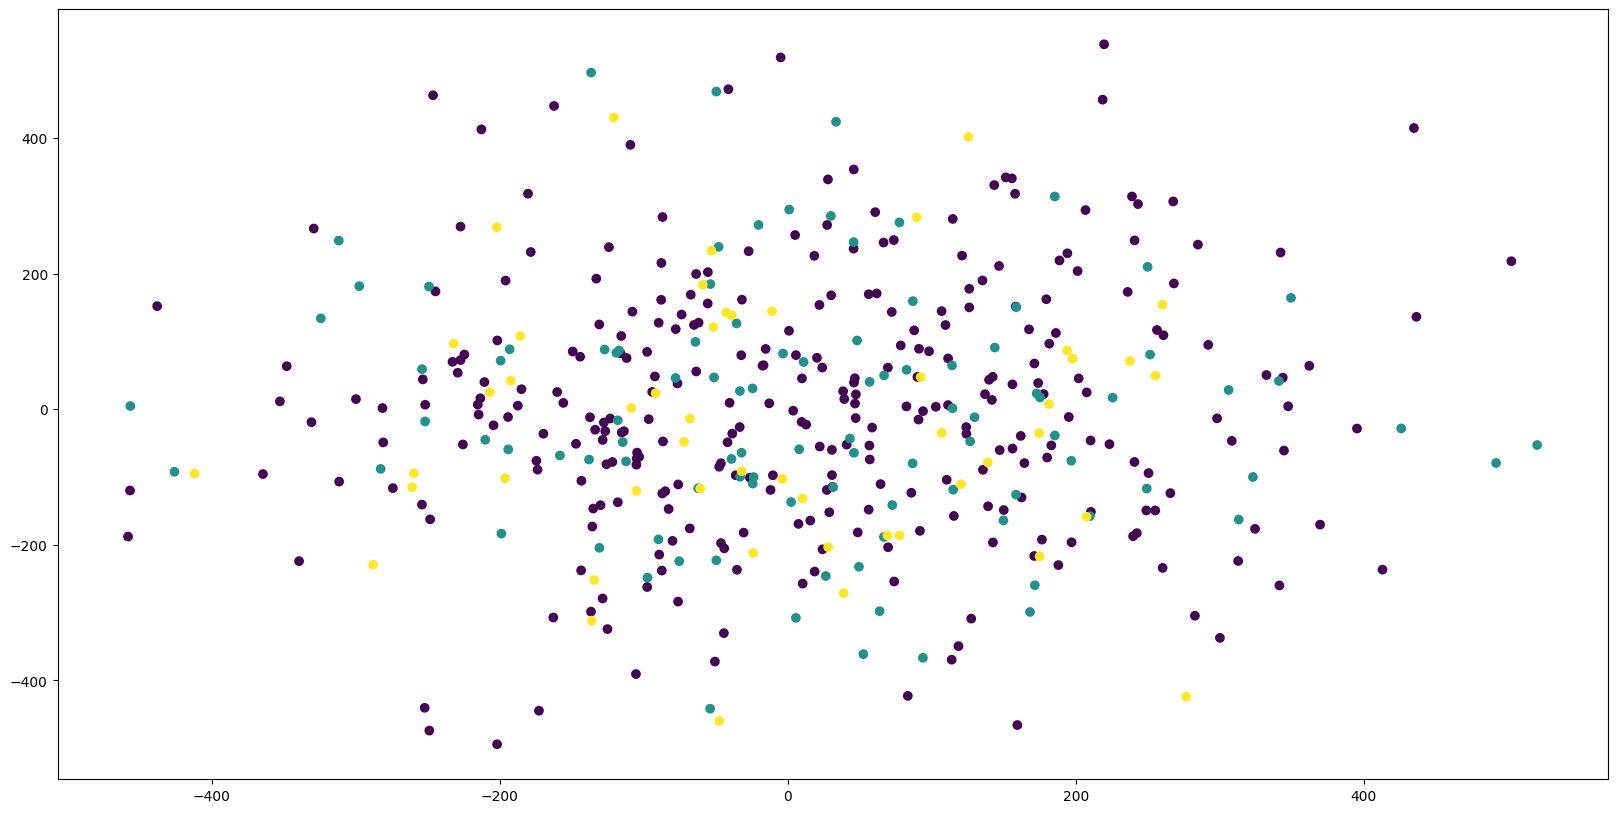

In [ ]:
ax1 = plt.scatter(xs[:,0], xs[:,1], c=ys)

In [ ]:
class RDAClassifier():
  def __init__(self, lmbda):
    self.lmbda = lmbda

  def fit(self, xs, ys):
    n_0 = numpy.where(ys==0.0)[0].shape[0]
    n_1 = numpy.where(ys==1.0)[0].shape[0]
    n_2 = numpy.where(ys==2.0)[0].shape[0]
    x_0 = xs[numpy.where(ys == 0.0)[0],:]
    x_1 = xs[numpy.where(ys == 1.0)[0], :]
    x_2 = xs[numpy.where(ys == 2.0)[0], :]
    self.mu_0 = numpy.mean(x_0, axis=0)
    self.mu_1 = numpy.mean(x_1, axis=0)
    self.mu_2 = numpy.mean(x_2, axis=0)
    N = n_0 + n_1 + n_2
    sigma_0 = 1/(N - 3)*numpy.matmul((x_0 - self.mu_0).T, x_0 - self.mu_0)
    sigma_1 = 1/(N - 3)*numpy.matmul((x_1 - self.mu_1).T, x_1 - self.mu_1)
    sigma_2 = 1/(N - 3)*numpy.matmul((x_2 - self.mu_1).T, x_2 - self.mu_2)

    self.pi_0 = n_0/N
    self.pi_1 = n_1/N
    self.pi_2 = n_2/N
    self.sigma = sigma_0 + sigma_1 + sigma_2
    self.sigma = (self.sigma + self.sigma.T)/2
    self.sigma_lmbda = self.lmbda * self.sigma + (1 - self.lmbda)*numpy.diag(self.sigma.diagonal())
    return RDAClassifierResult(self.pi_0,
                               self.pi_1,
                               self.pi_2,
                               self.mu_0,
                               self.mu_1,
                               self.mu_2,
                               self.sigma,
                               self.sigma_lmbda)

class RDAClassifierResult():
  def __init__(self, pi_0, pi_1, pi_2, mu_0, mu_1, mu_2, sigma, sigma_lambda):
    self.pi_0 = pi_0
    self.pi_1 = pi_1
    self.pi_2 = pi_2
    self.mu_0 = mu_0
    self.mu_1 = mu_1
    self.mu_2 = mu_2
    self.sigma = sigma
    self.sigma_lambda = sigma_lambda

  def predict(self, x):
    LL = self._log_loss(x)
    return self._softmax(LL)

  def _softmax(self, vec):
    new_vec = numpy.append([0], vec)
    return numpy.exp(new_vec)/(numpy.sum(numpy.exp(new_vec)))


  def viz_everything(self):
    sigma_inv = numpy.linalg.inv(self.sigma_lambda)
    x_hat = numpy.matmul(sigma_inv, self.mu_0 - self.mu_1)
    offset = numpy.log(self.pi_1/self.pi_0) + 1/2*numpy.log(numpy.linalg.det(self.sigma_lambda)*2*numpy.pi)
    slope = -1*x_hat[0]/x_hat[1]
    intercept = offset/x_hat[1]
    t = numpy.arange(-2, 2, 0.1)
    return (t, slope*t + intercept)

  def _log_loss(self, x):
    sigma_inv = numpy.linalg.inv(self.sigma_lambda)
    sigma_inv_dist_01 = numpy.matmul(sigma_inv, self.mu_1 - self.mu_0)
    first_term_01 = -1/2*numpy.matmul(self.mu_1 + self.mu_0, sigma_inv_dist_01)
    second_term_01 = numpy.matmul(x, sigma_inv_dist_01)
    third_term_01 = numpy.log(self.pi_1/self.pi_0)
    sigma_inv_dist_02 = numpy.matmul(sigma_inv, self.mu_2 - self.mu_0)
    first_term_02 = -1/2*numpy.matmul(self.mu_2 + self.mu_0, sigma_inv_dist_02)
    second_term_02 = numpy.matmul(x, sigma_inv_dist_02)
    third_term_02 = numpy.log(self.pi_2/self.pi_0)
    return (first_term_01 + second_term_01 + third_term_01,
            first_term_02 + second_term_02 + third_term_02 )

In [ ]:
model = RDAClassifier(0.7)

In [ ]:
U, D, Vt = numpy.linalg.svd(xs, full_matrices=False)

In [ ]:
U.shape

(450, 450)

In [ ]:
U.diagonal().shape

(450,)

In [ ]:
D.shape

(450,)

In [ ]:
Vt.shape

(450, 1000)

In [ ]:
R = numpy.matmul(U, numpy.diag(D))

In [ ]:
result = model.fit(R, ys)

In [ ]:
result.sigma.shape

(450, 450)

In [ ]:
eig_vals, eig_vects = numpy.linalg.eig(result.sigma)
numpy.sort(eig_vals)[:4]

array([-1.08921260e-10,  4.54761857e-11,  2.58676693e-10,  2.92897110e+03])

In [ ]:
eig_vals, eig_vects = numpy.linalg.eig(result.sigma_lambda)
numpy.sort(eig_vals)[-4:]
eig_vals.max()/eig_vals.min()

np.float64(105.2175135174078)

In [ ]:
test = numpy.matmul(rng.uniform(high=10, low=10, size=1000), Vt.T)

In [ ]:
result.predict(test)

array([9.99168343e-01, 8.31413766e-04, 2.43145690e-07])

In [ ]:
t, line = result.viz_everything()

/usr/local/lib/python3.11/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


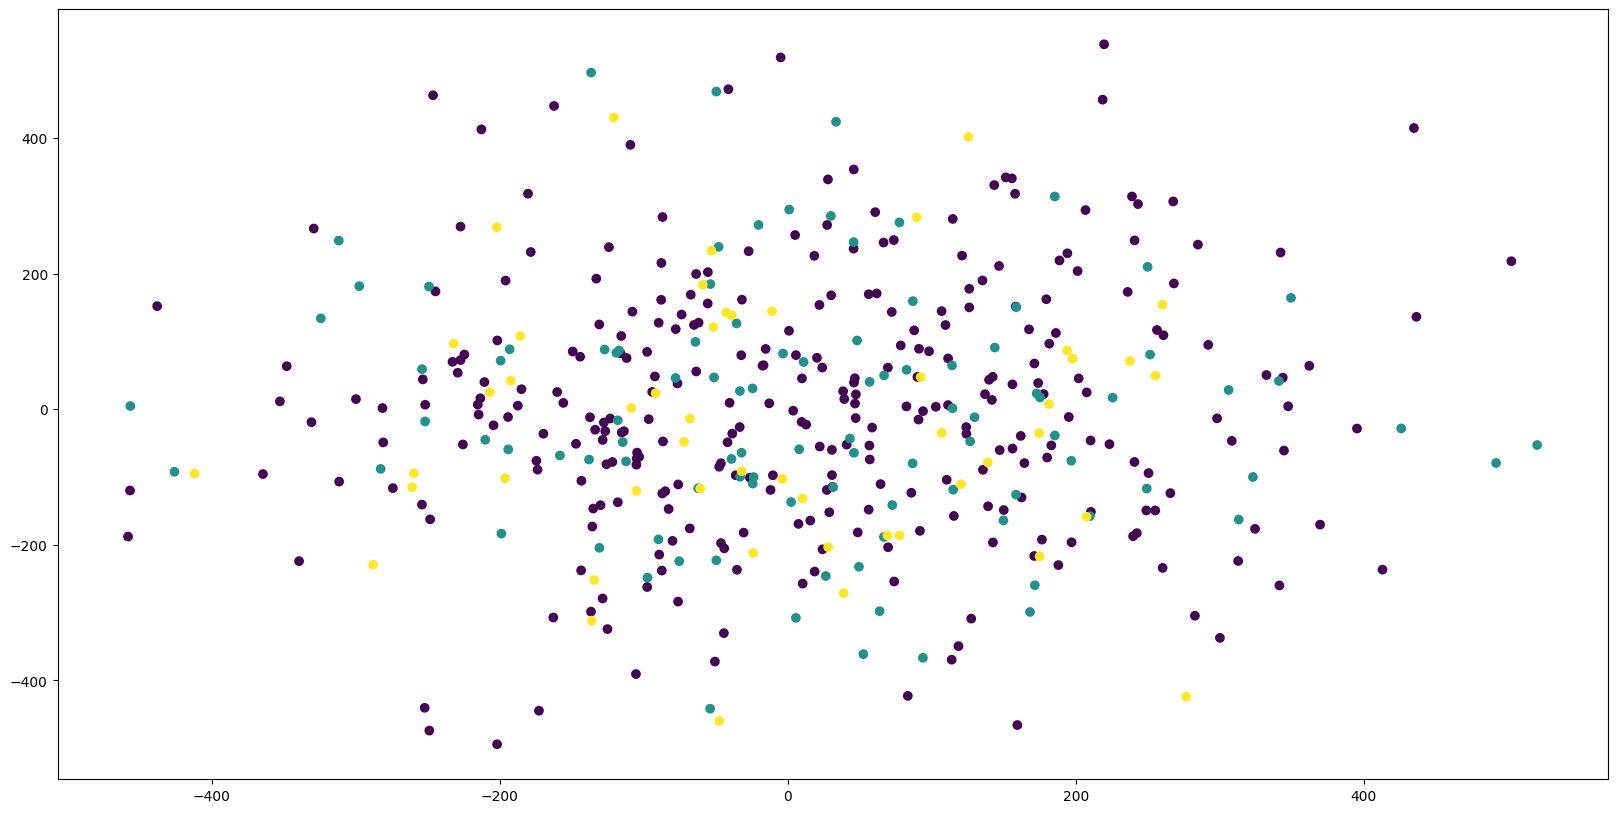

In [ ]:
plt.plot(t, line)
plt.scatter(xs[:,0], xs[:,1], c=ys)

In [ ]:
numpy.linalg.inv(result.sigma_lambda)

array([[ 3.38432264e-06,  2.61249873e-09,  1.84719482e-08, ...,
         7.26312743e-08,  5.39489989e-09, -1.46777131e-07],
       [ 2.61249873e-09,  3.44410777e-06,  5.69032721e-09, ...,
         7.78682489e-08,  5.50811029e-08,  1.77133655e-07],
       [ 1.84719482e-08,  5.69032721e-09,  3.54146530e-06, ...,
         1.48075598e-07,  2.95763724e-08, -2.65917275e-07],
       ...,
       [ 7.26312743e-08,  7.78682489e-08,  1.48075598e-07, ...,
         2.90309938e-04,  2.64021124e-07, -8.19403431e-07],
       [ 5.39489989e-09,  5.50811029e-08,  2.95763724e-08, ...,
         2.64021124e-07,  3.17639072e-04,  8.45604906e-08],
       [-1.46777131e-07,  1.77133655e-07, -2.65917275e-07, ...,
        -8.19403431e-07,  8.45604906e-08,  3.53138075e-04]])

# Supervised Dimensionality Reduction

In [ ]:
def generate_classifier_data(rnge, k, d, sizes, seed):


    rng = numpy.random.default_rng(seed=seed)
    cs = rng.uniform(rnge[0], rnge[1], size=(k, d))
    mb = rng.normal(loc=0, scale=.3, size=(k,d))
    noise = rng.normal(loc=0, scale=0.01, size=(d,d))
    sigma_signal = numpy.matmul(mb.T, mb)
    noisy_sigma = sigma_signal + noise
    sigma = numpy.matmul(noisy_sigma.T, noisy_sigma)
    classes = [rng.multivariate_normal(c, sigma, size=size) for c, size in zip(cs,sizes)]
    ys = [j*numpy.ones(shape=(size, 1)) for j, size in enumerate(sizes)]
    xs = numpy.vstack(classes)
    ys = numpy.vstack(ys)
    return (xs, ys)


In [ ]:
rnge = [-100,100]
k = 3
d = 2500
sizes = [50, 10, 20]
X, y = generate_classifier_data(rnge, k, d, sizes, 8675309)
X.shape

(80, 2500)

In [ ]:
U, D, Vt = numpy.linalg.svd(X, full_matrices=False)
R = numpy.matmul(U, numpy.diag(D))

In [ ]:
model = RDAClassifier(0.01)
result = model.fit(R,y)

In [ ]:
inv_sigma = numpy.linalg.inv(result.sigma_lambda)
p = numpy.linalg.eig(inv_sigma)[1][:,-2:]

In [ ]:
p.shape

(80, 2)

In [ ]:
numpy.matmul(p.T, p)

array([[ 1.00000000e+00, -3.63299967e-15],
       [-3.63299967e-15,  1.00000000e+00]])

In [ ]:
numpy.linalg.eigvals(result.sigma_lambda)

array([6.47172683e+04, 4.53076278e+04, 5.78807906e+04, 1.91572321e+02,
       3.06910662e+01, 3.18961210e+00, 1.26184680e+01, 1.20203686e+01,
       1.17288756e+01, 1.15772744e+01, 1.14538093e+01, 1.11525822e+01,
       1.11879705e+01, 1.09852133e+01, 1.08477015e+01, 1.06747889e+01,
       4.72577263e+00, 4.82363526e+00, 1.04849721e+01, 1.04051082e+01,
       5.03718040e+00, 1.02271715e+01, 1.00611738e+01, 9.97398055e+00,
       9.87666554e+00, 5.29464184e+00, 5.33604300e+00, 9.69158357e+00,
       5.45450464e+00, 5.47898413e+00, 5.55296286e+00, 5.60739919e+00,
       9.61481947e+00, 9.57985228e+00, 9.40479821e+00, 9.48397471e+00,
       9.30549253e+00, 5.73595448e+00, 9.22648350e+00, 9.14279355e+00,
       5.81576473e+00, 5.77530160e+00, 5.88991839e+00, 5.96339488e+00,
       6.05650918e+00, 9.01377054e+00, 8.84269158e+00, 9.03296841e+00,
       8.69422417e+00, 8.63801590e+00, 6.25490761e+00, 6.27313801e+00,
       8.51313741e+00, 8.45433632e+00, 6.31568900e+00, 8.30189201e+00,
      

In [ ]:
X_p = numpy.matmul(R, p)

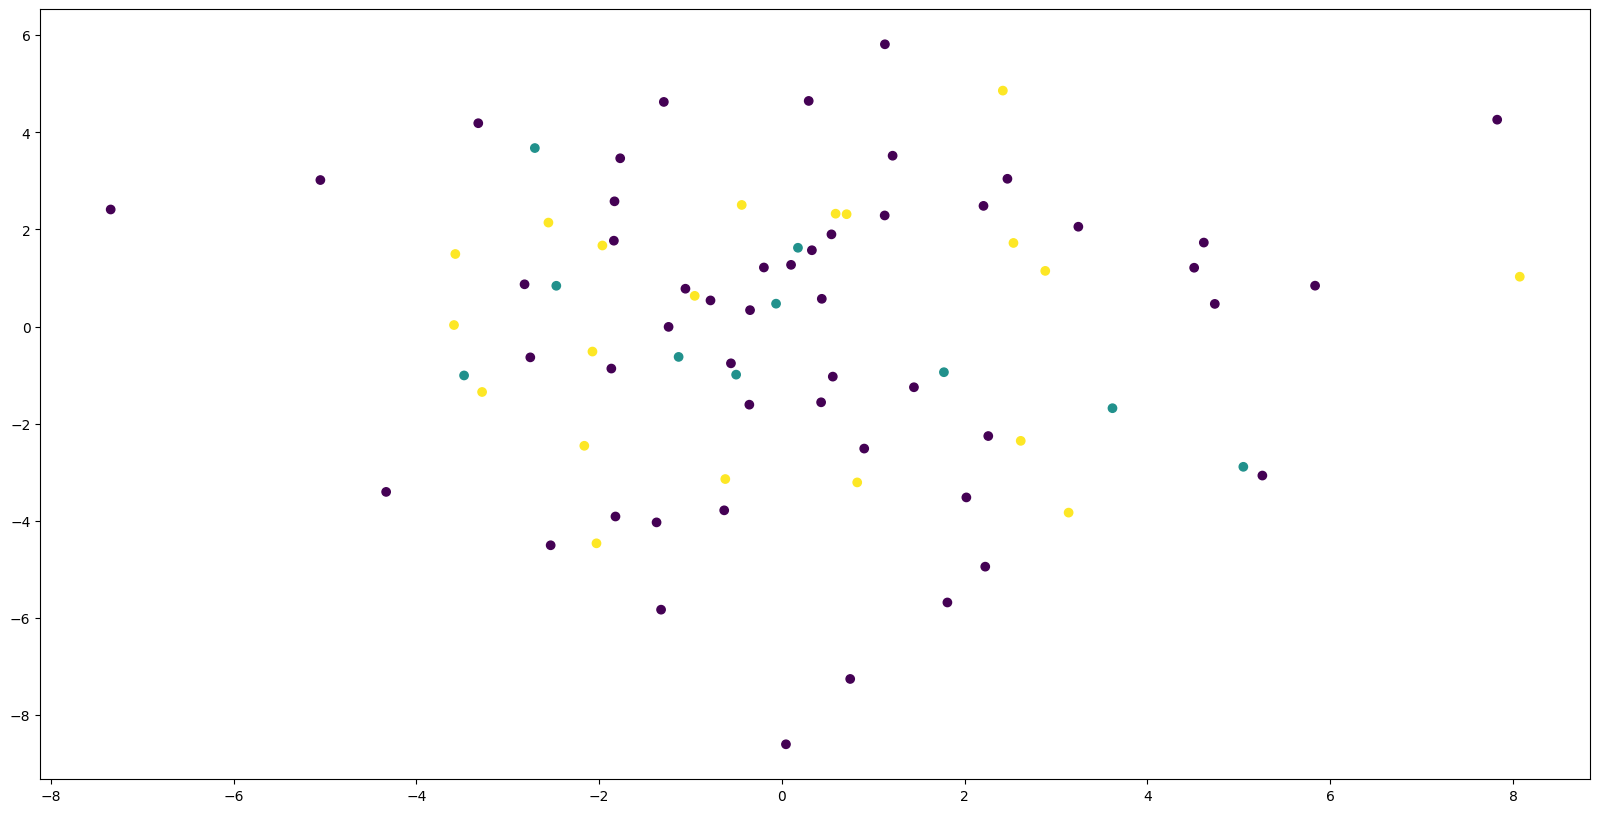

In [ ]:
plt.scatter(X_p[:,0], X_p[:,1], c=y)
plt.show()